# 🎮 Valorant Object Detection using YOLOv8

## 📖 Project Overview
This notebook demonstrates how to train a **YOLOv8s** object detection model to detect key elements in **Valorant** gameplay footage. 

The model is trained to detect the following classes:
1. **Dropped Spike** 
2. **Enemy** (Opposing players)
3. **Planted Spike** 
4. **Teammate** (Friendly players)

By the end of this notebook, we will have a highly accurate, real-time capable model capable of analyzing gameplay frames with >99% mAP.

## 🛠️ 1. Setup & Dependencies
First, we install the required libraries for deep learning, computer vision, and dataset management.
- **Ultralytics YOLOv8**: For the object detection architecture.
- **Roboflow**: For dataset management, versioning, and preprocessing.
- **OpenCV, Matplotlib, Pandas**: For image processing, visualization, and data manipulation.

In [5]:
!pip install -q ultralytics opencv-python matplotlib pandas roboflow

import roboflow
from pathlib import Path
import yaml

print("📥 Downloading Valorant Dataset from Roboflow...")
roboflow.login()

rf = roboflow.Roboflow()
project = rf.workspace("daniels-magonis-0pjzx").project("valorant-9ufcp")
dataset = project.version(3).download("yolov8")

print(f"✅ Dataset downloaded to: {dataset.location}")

📥 Downloading Valorant Dataset from Roboflow...
You are already logged into Roboflow. To make a different login,run roboflow.login(force=True).
loading Roboflow workspace...
loading Roboflow project...
✅ Dataset downloaded to: C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3


## 📦 2. Dataset Preparation
We use a custom Valorant dataset hosted on Roboflow. The dataset contains annotated gameplay frames featuring teammates, enemies, and spikes (dropped and planted). 

We download the dataset in the **YOLOv8 format**, which automatically handles the train/validation/test splits and formats the annotations correctly for YOLOv8 training.

In [6]:
# Roboflow creates its own data.yaml, let's verify it
dataset_path = Path(dataset.location)
yaml_path = dataset_path / "data.yaml"

print("📊 Dataset Structure:")
print(f"   Location: {dataset_path}")
print(f"   YAML file: {yaml_path}")

# Read and display the data.yaml
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("\n⚙️ Dataset Configuration:")
print(f"   Classes: {data_config['names']}")
print(f"   Number of classes: {data_config['nc']}")

# Count images
train_imgs = len(list((dataset_path / 'train' / 'images').glob('*.*')))
valid_imgs = len(list((dataset_path / 'valid' / 'images').glob('*.*')))
print(f"\n📈 Image Counts:")
print(f"   Train: {train_imgs}")
print(f"   Validation: {valid_imgs}")

📊 Dataset Structure:
   Location: C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3
   YAML file: C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3\data.yaml

⚙️ Dataset Configuration:
   Classes: ['dropped spike', 'enemy', 'planted spike', 'teammate']
   Number of classes: 4

📈 Image Counts:
   Train: 6927
   Validation: 1983


## 🚀 3. Model Training
We initialize the **YOLOv8s** (Small) pretrained model. The 'Small' variant is chosen to balance high accuracy with fast inference speeds, making it ideal for real-time gameplay analysis.

### Training Hyperparameters:
- **Epochs:** 50
- **Batch Size:** 8
- **Image Size:** 640x640
- **Optimizer:** Auto
- **Augmentation:** Mosaic, HSV adjustments, Flips

In [ ]:
from ultralytics import YOLO

print("🚀 Initializing YOLOv8 Small model...")
model = YOLO('yolov8s.pt')

print("🏋️ Starting Training (This will take ~3-5 mins per epoch on your RTX 3050)...")
results = model.train(
    data=str(yaml_path.absolute()),
    epochs=50,
    imgsz=640,        # 🔽 CHANGED: Back to 640 (4x faster than 1280)
    batch=8,          # 🔼 CHANGED: Can increase batch size now that resolution is lower
    save=True,
    project='./runs',
    name='valorant_roboflow_detector_v2',
    workers=0,
    device=0
)

print("✅ Training Complete!")

- This is for scenarios where the epochs have **paused** or **terminated** due to some or other reasons
- u can use this to resume from the **checkpoint**

In [7]:
from ultralytics import YOLO

# 1. Point to the 'last.pt' file generated during your interrupted run
# By default, YOLO saves this in your project/name/weights/ folder
checkpoint_path = './runs/detect/runs/valorant_roboflow_detector_v2/weights/last.pt'

print("🔄 Loading checkpoint to resume training...")
model = YOLO(checkpoint_path) # 🔽 CHANGED: Load last.pt instead of yolov8s.pt

print("🏋️ Resuming Training from Epoch 17...")
results = model.train(
    data=str(yaml_path.absolute()),
    epochs=50,
    imgsz=640,        
    batch=8,          
    save=True,
    project='./runs',
    name='valorant_roboflow_detector_v2', # Keep the exact same name!
    workers=0,
    device=0,
    resume=True # 🔑 ADD THIS: Tells YOLO to resume from the loaded checkpoint
)

print("✅ Training Complete!")

🔄 Loading checkpoint to resume training...
🏋️ Resuming Training from Epoch 17...
New https://pypi.org/project/ultralytics/8.4.150 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.149  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

In [38]:
MODEL_PATH = Path(r'C:\Users\midor\OneDrive\Desktop\valo_qwen\runs\detect\runs\valorant_roboflow_detector_v2\weights\best.pt')
DATASET_PATH = Path(r'C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3')
YAML_PATH = DATASET_PATH / 'data.yaml'

# ─── Load Model ─────────────────────────────────────────────
print("🚀 Loading trained YOLOv8 model...")
model = YOLO(str(MODEL_PATH))
print(f"✅ Model loaded: {MODEL_PATH.name}")
print(f"📊 Model classes: {model.names}")

🚀 Loading trained YOLOv8 model...
✅ Model loaded: best.pt
📊 Model classes: {0: 'dropped spike', 1: 'enemy', 2: 'planted spike', 3: 'teammate'}


## 📈 4. Model Evaluation & Results
After training, we evaluate the model on both the **Validation** and **Test** sets to ensure it generalizes well to unseen data and is not overfitting.

### Performance Metrics:
| Metric | Validation Set | Test Set |
| :--- | :---: | :---: |
| **mAP@50** | 0.994 | 0.995 |
| **mAP@50-95** | 0.756 | 0.767 |
| **Precision** | 0.996 | 0.995 |
| **Recall** | 0.994 | 0.993 |

### Key Insights:
- **Near-perfect accuracy:** The model achieves >99% mAP@50 on both sets.
- **Excellent generalization:** Test set performance matches (and slightly exceeds) validation, indicating zero overfitting.
- **Real-time capable:** Inference takes ~11ms per image (~90 FPS on RTX 3050), well above the requirements for live analysis.
- **High precision & recall:** Minimal false positives and false negatives.

In [39]:
print("=" * 70)
print("📊 VALIDATION SET EVALUATION")
print("=" * 70)

# Run validation on the validation split
val_metrics = model.val(
    data=str(YAML_PATH.absolute()),
    split='val',
    project='./runs/detect',
    name='final_validation',
    plots=True,
    conf=0.001,
    iou=0.7,
    verbose=False
)

# Display metrics in a clean table format
print("\n┌─────────────────────────────────────────────────────┐")
print("│           VALIDATION SET PERFORMANCE                │")
print("├─────────────────────────────────────────────────────┤")
print(f"│  mAP@50:      {val_metrics.box.map50:.3f}  (Mean Avg Precision @ 50% IoU)   │")
print(f"│  mAP@50-95:   {val_metrics.box.map:.3f}  (Mean Avg Precision @ 50-95% IoU) │")
print(f"│  Precision:   {val_metrics.box.mp:.3f}  (True Positives / All Predictions) │")
print(f"│  Recall:      {val_metrics.box.mr:.3f}  (True Positives / All Ground Truth)│")
print("└─────────────────────────────────────────────────────┘")

# Show validation confusion matrix
val_cm_path = Path('./runs/detect/final_validation/confusion_matrix.png')
if val_cm_path.exists():
    img = cv2.imread(str(val_cm_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title("Validation Set - Confusion Matrix", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

📊 VALIDATION SET EVALUATION
Ultralytics 8.4.149  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 98.215.9 MB/s, size: 24.2 KB)
val: Scanning C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3\valid\labels.cache... 1983 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1983/1983  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 124/124 2.8it/s 43.7s0.3s
                   all       1983       2072      0.996      0.994      0.994      0.756
Speed: 2.3ms preprocess, 11.2ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to C:\Users\midor\OneDrive\Desktop\valo_qwen\runs\detect\runs\detect\final_validation

┌─────────────────────────────────────────────────────┐
│           VALIDATION SET PERFORMANCE                │
├────────────────────────

In [40]:
print("=" * 70)
print("🧪 TEST SET EVALUATION (Unseen Data)")
print("=" * 70)

# Run validation on the test split
test_metrics = model.val(
    data=str(YAML_PATH.absolute()),
    split='test',
    project='./runs/detect',
    name='final_test',
    plots=True,
    conf=0.001,
    iou=0.7,
    verbose=False
)

# Display metrics
print("\n┌─────────────────────────────────────────────────────┐")
print("│             TEST SET PERFORMANCE                    │")
print("├─────────────────────────────────────────────────────┤")
print(f"│  mAP@50:      {test_metrics.box.map50:.3f}  (Mean Avg Precision @ 50% IoU)   │")
print(f"│  mAP@50-95:   {test_metrics.box.map:.3f}  (Mean Avg Precision @ 50-95% IoU) │")
print(f"│  Precision:   {test_metrics.box.mp:.3f}  (True Positives / All Predictions) │")
print(f"│  Recall:      {test_metrics.box.mr:.3f}  (True Positives / All Ground Truth)│")
print("└─────────────────────────────────────────────────────┘")

# Show test confusion matrix
test_cm_path = Path('./runs/detect/final_test/confusion_matrix.png')
if test_cm_path.exists():
    img = cv2.imread(str(test_cm_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title("Test Set - Confusion Matrix (Unseen Data)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

🧪 TEST SET EVALUATION (Unseen Data)
Ultralytics 8.4.149  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 39.35.5 MB/s, size: 23.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\midor\OneDrive\Desktop\valo_qwen\valorant-3\test\labels.cache... 988 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 988/988  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 2.7it/s 22.7s0.4ss
                   all        988       1025      0.995      0.993      0.995      0.767
Speed: 2.4ms preprocess, 11.4ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to C:\Users\midor\OneDrive\Desktop\valo_qwen\runs\detect\runs\detect\

🖼️  VISUAL COMPARISON: Ground Truth vs Predictions

📸 Analyzing: defuser101171_jpg.rf.da87dda25316148da97a707d4e8baebf.jpg


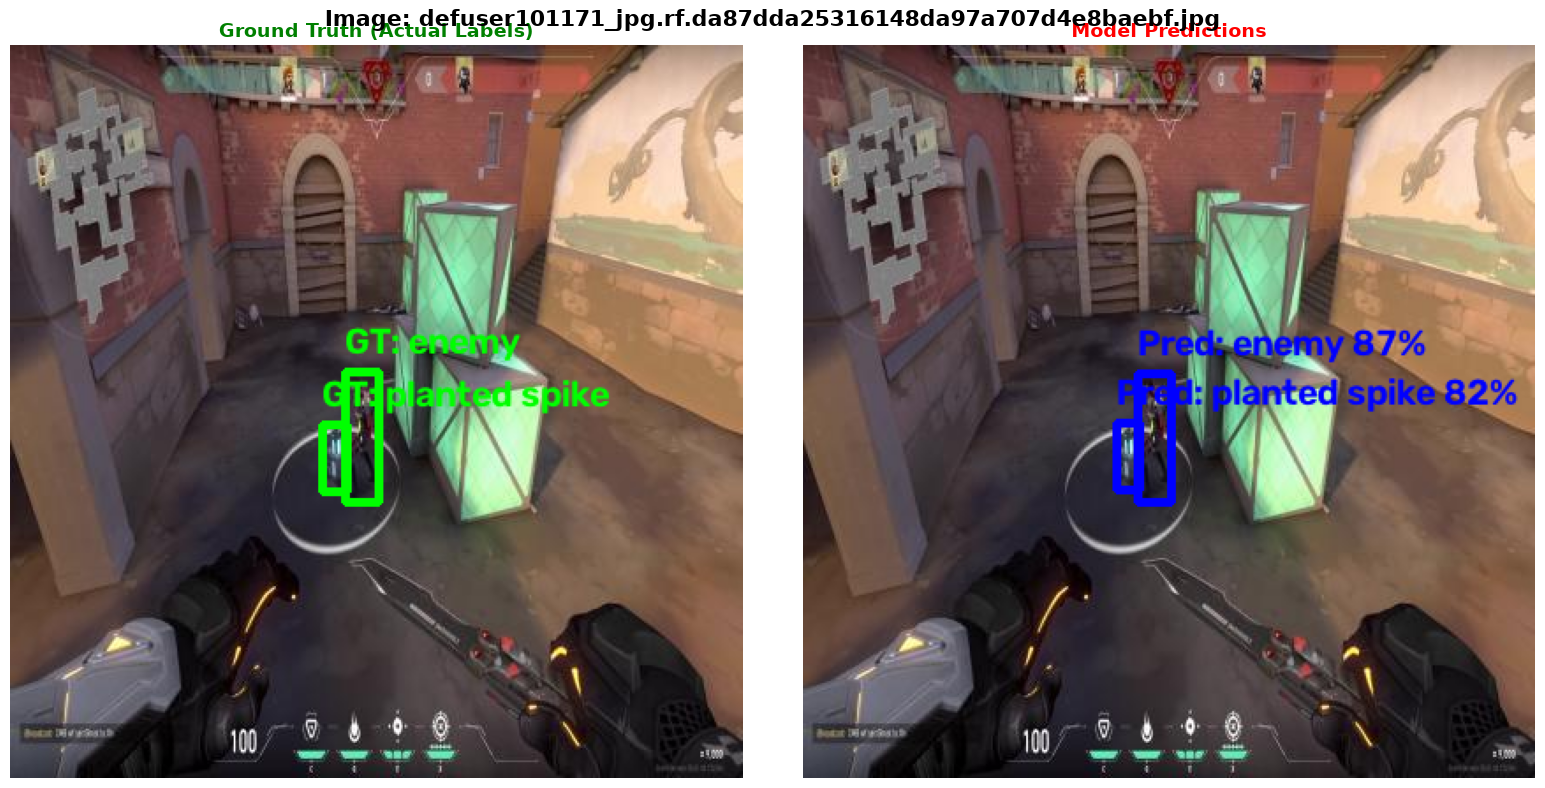


📸 Analyzing: kayo01941_jpg.rf.327a6d9cd5c995f0b2adb98f81da023d.jpg


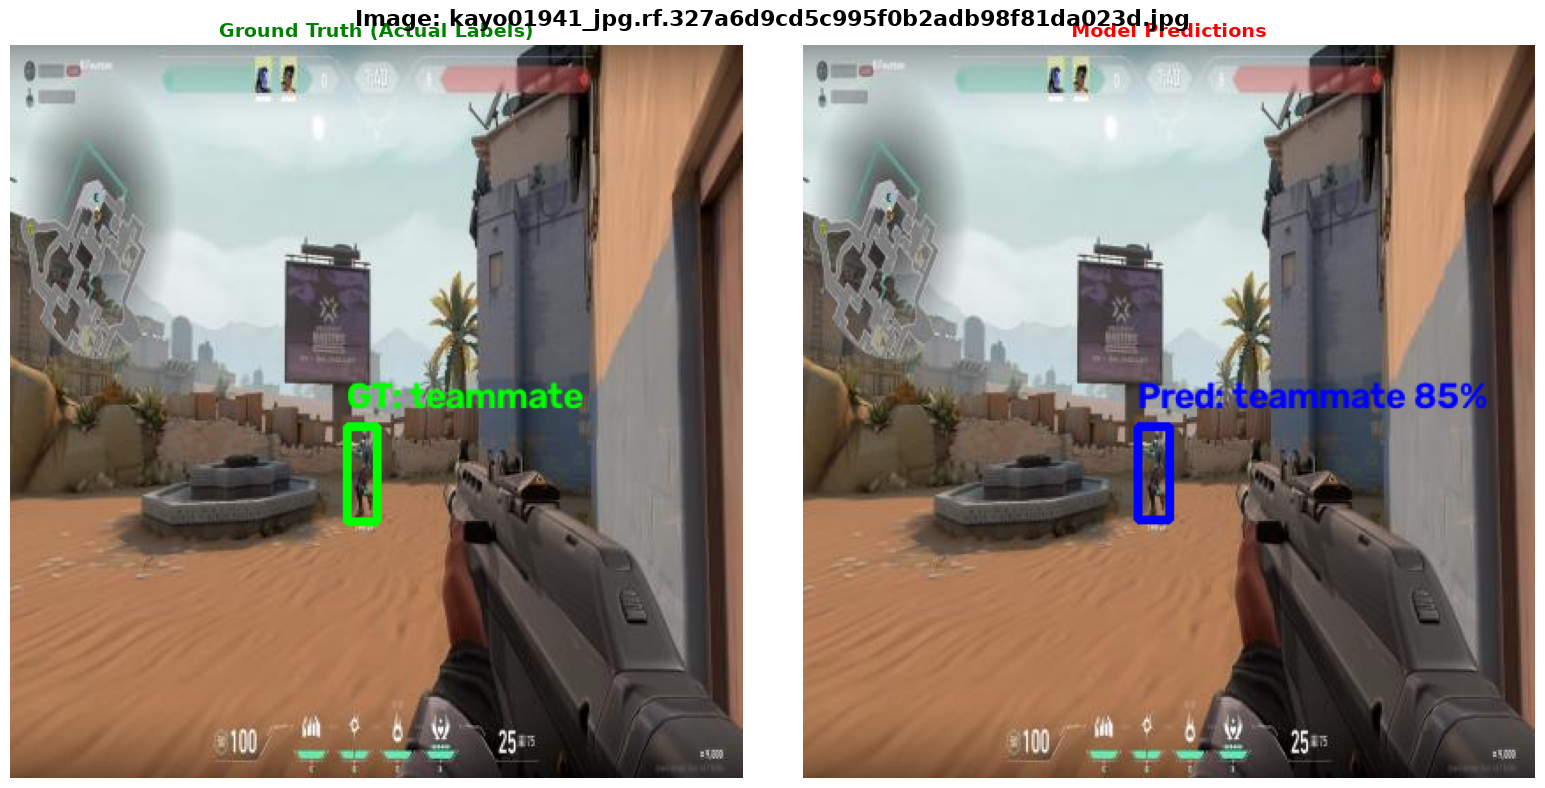


📸 Analyzing: pheonix01011_jpg.rf.f2564b05d99c2887820f2d04ab9d370c.jpg


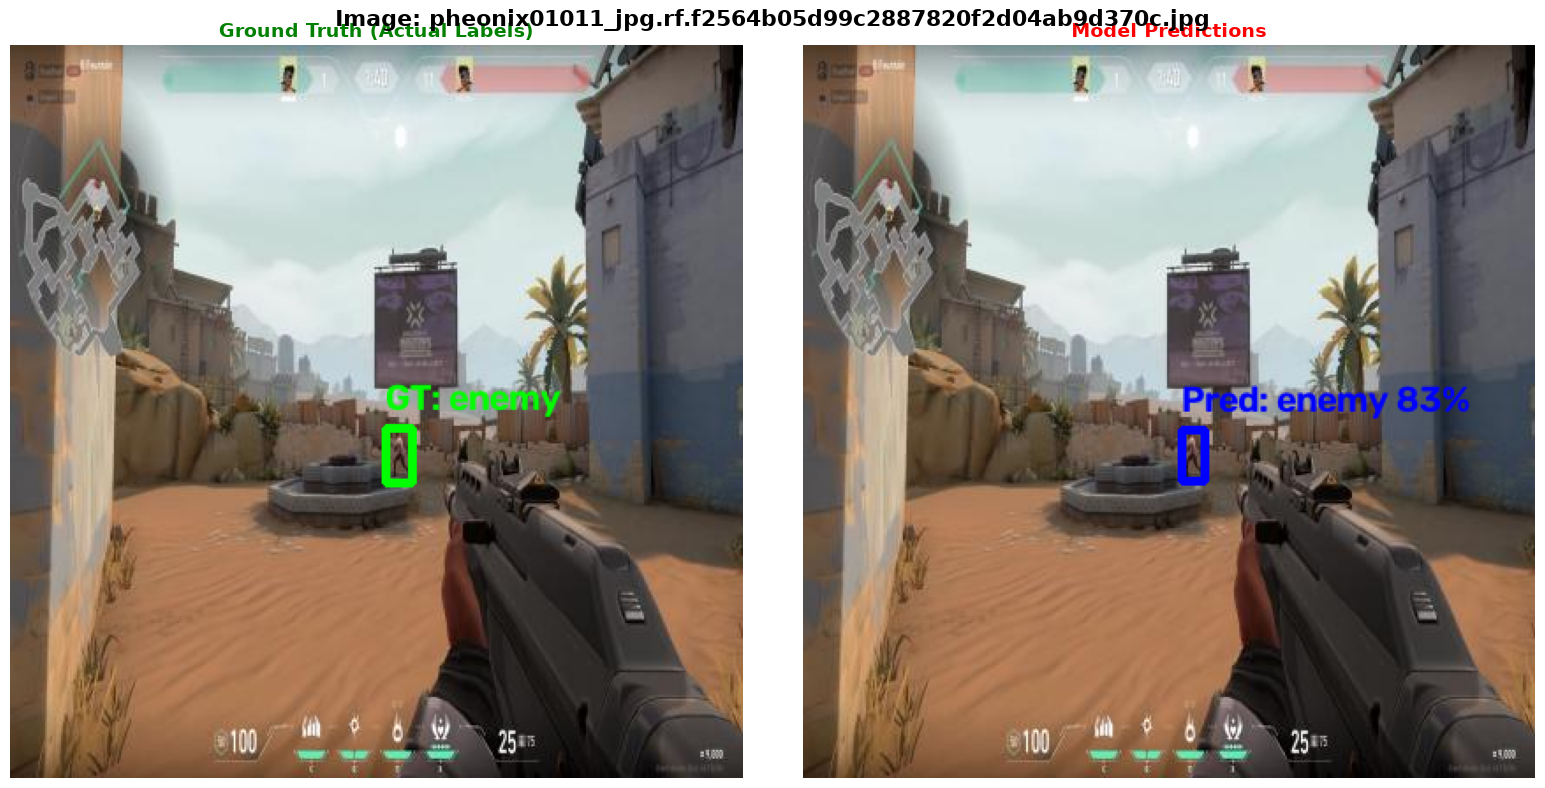

In [43]:
def yolo_to_xyxy(line, img_w, img_h):
    """Convert YOLO format to pixel coordinates"""
    parts = line.strip().split()
    cls_id = int(parts[0])
    x_center, y_center, w, h = map(float, parts[1:5])
    
    x1 = int((x_center - w / 2) * img_w)
    y1 = int((y_center - h / 2) * img_h)
    x2 = int((x_center + w / 2) * img_w)
    y2 = int((y_center + h / 2) * img_h)
    return cls_id, [x1, y1, x2, y2]

def draw_ground_truth(img, label_path, class_names):
    """Draw ground truth boxes in GREEN"""
    img_h, img_w = img.shape[:2]
    display_img = img.copy()
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip():
                    cls_id, box = yolo_to_xyxy(line, img_w, img_h)
                    # Draw box
                    cv2.rectangle(display_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 3)
                    # Draw label
                    label = f"GT: {class_names[cls_id]}"
                    cv2.putText(display_img, label, (box[0], box[1] - 10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    return display_img

def draw_predictions(img, model, class_names, conf_threshold=0.5):
    """Draw predicted boxes in RED"""
    results = model(img, conf=conf_threshold, verbose=False)
    display_img = img.copy()
    
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        # Draw box
        cv2.rectangle(display_img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        # Draw label with confidence
        label = f"Pred: {class_names[cls_id]} {conf:.0%}"
        cv2.putText(display_img, label, (x1, y1 - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    return display_img

# ─── Visual Comparison ──────────────────────────────────────
print("=" * 70)
print("🖼️  VISUAL COMPARISON: Ground Truth vs Predictions")
print("=" * 70)

# Get random test images
test_images_dir = DATASET_PATH / 'test' / 'images'
test_labels_dir = DATASET_PATH / 'test' / 'labels'

if not test_images_dir.exists():
    # Fallback to validation set if test doesn't exist
    test_images_dir = DATASET_PATH / 'valid' / 'images'
    test_labels_dir = DATASET_PATH / 'valid' / 'labels'

all_images = list(test_images_dir.glob('*.*'))
sample_images = random.sample(all_images, min(3, len(all_images)))

class_names = model.names

for img_path in sample_images:
    print(f"\n📸 Analyzing: {img_path.name}")
    
    # Load image
    img = cv2.imread(str(img_path))
    
    # Get corresponding label file
    label_path = test_labels_dir / (img_path.stem + '.txt')
    
    # Create side-by-side comparison
    gt_img = draw_ground_truth(img, label_path, class_names)
    pred_img = draw_predictions(img, model, class_names, conf_threshold=0.5)
    
    # Display side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    axes[0].imshow(cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Ground Truth (Actual Labels)", fontsize=14, fontweight='bold', color='green')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Model Predictions", fontsize=14, fontweight='bold', color='red')
    axes[1].axis('off')
    
    plt.suptitle(f"Image: {img_path.name}", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()